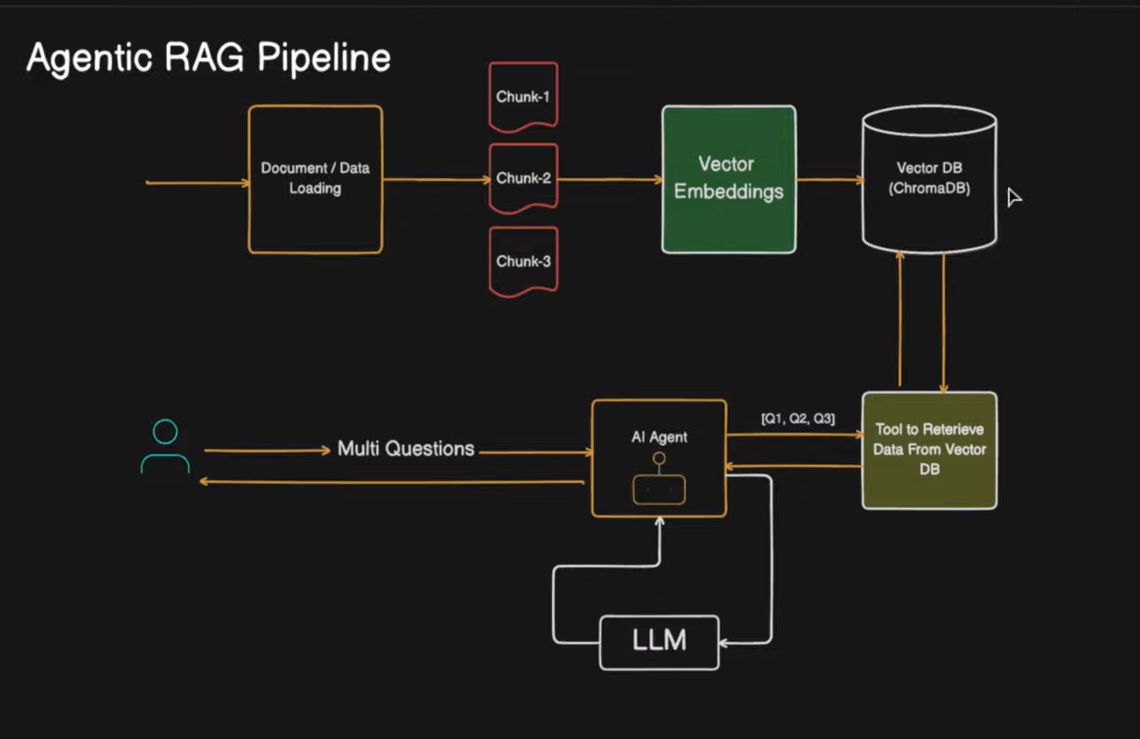

In [17]:
from IPython.display import Image, display

img_path = r"D:\GENAI\Images\Agentic_Rag.png"
display(Image(filename=img_path))

In [18]:
from dotenv import load_dotenv
load_dotenv()

True

In [19]:
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_ollama import OllamaEmbeddings,ChatOllama
from langchain_community.vectorstores import InMemoryVectorStore
from langchain_core.prompts import ChatPromptTemplate
from langchain.tools import tool
from langchain.agents import create_agent


In [20]:
loader=PyPDFLoader(r"C:\Users\ashut\Downloads\Gen AI Workflow Specialist-Engineer.pdf")
docs=loader.load()


In [21]:
len(docs)

4

In [22]:
splitter=RecursiveCharacterTextSplitter(chunk_size=1000,chunk_overlap=200)
splitter_docs=splitter.split_documents(docs)

In [23]:
len(splitter_docs)

8

In [24]:
embeddings=OllamaEmbeddings(model="mxbai-embed-large")
vector_store=InMemoryVectorStore.from_documents(
    documents=splitter_docs,
    embedding=embeddings
)

In [25]:
## Agents = Tools,llm,Prompt


In [26]:

@tool
def retriever_tool(query:str):
    """
    This tool can help you to retrieve relevant information from the document based on the query.
    """
    print("Tool Called: ", query)
    docs=vector_store.similarity_search(query=query,k=4)
    print(len(docs), docs[0].page_content)
    context=""
    for doc in docs:
        context=doc.page_content+"\n\n"
    return context

In [27]:
retriever_tool.invoke("""Step 1: Find skills required for Gen AI Workflow Specialist-Engineer using the tool.

Step 2: Find responsibilities using the tool again.

Step 3: Compare both.""")

Tool Called:  Step 1: Find skills required for Gen AI Workflow Specialist-Engineer using the tool.

Step 2: Find responsibilities using the tool again.

Step 3: Compare both.
4 ROLE OVERVIEW 
As a Gen AI Workflow Specialist / Engineer, you’ll design and operationalize end-to-end 
generative pipelines that convert product SKUs into photorealistic lifestyle visuals, 
human+AI model compositions, and cinematic videos. 
You’ll work hands-on with open-source Gen AI frameworks (Stable Diffusion, SDXL, 
LORA, ControlNet, AnimateDiff, WAN2.5, etc.) and integrate them into secure on-prem 
or hybrid GPU environments. 
Your mission: build creative intelligence systems that make AI-generated imagery and 
video indistinguishable from high-end studio production. 
 
KEY RESPONSIBILITIES 
1. Workflow & Pipeline Engineering 
• Design modular Gen AI workflows that transform product SKUs into lifestyle 
imagery, compositing jewellery, fashion, or accessories onto generated models.


'Engineer 3–5 years \nDeep expertise in AI workflow design and orchestration. \nProficiency in SDXL / LORA / ControlNet / model fine-tuning / \non-prem GPU deployment. Capable of architecting enterprise-\ngrade AI creative systems and mentoring team members. \n \nCORE TECHNICAL SKILLS \n• Python, PyTorch, TensorFlow \n• Stable Diffusion, SDXL, WAN, RealVisXL, Runway \n• ControlNet, LORA, IP-Adapter, DreamBooth, AnimateDiff \n• ComfyUI / A1111 / Custom Node & API Integration \n• Upscaling: ESRGAN, SwinIR, CodeFormer, RealESRGAN \n• Human Model Generation: ReActor, InsightFace, HumanDiffusion\n\n'

In [28]:
llm=ChatOllama(model="llama3.2:latest")

In [29]:
System_prompt="""
You are a helpful assistant for answering questions related to Gen AI Workflow Specialist-Engineer role.
"""

In [30]:
agent=create_agent(
    model=llm,
    tools=[retriever_tool],
    system_prompt=System_prompt
)

In [31]:
query="What are the skills required for Gen AI Workflow Specialist-Engineer?"
response=agent.invoke({"messages":[{"role":"user","content":query}]})

In [32]:
result=response["messages"][-1].content
print(result)

The skills required for a Gen AI Workflow Specialist-Engineer include:

1. **Programming skills**: Proficiency in programming languages such as Python, Java, or C++ is necessary for working with AI workflows.
2. **Deep learning knowledge**: Understanding of deep learning concepts, including neural networks, reinforcement learning, and natural language processing, is essential for designing and implementing AI models.
3. **Workflow management**: Experience with workflow management tools such as Apache Airflow, AWS Step Functions, or Google Cloud Workflows Management is necessary for managing complex AI workflows.
4. **Data engineering**: Knowledge of data engineering concepts, including data preprocessing, feature engineering, and model training, is critical for preparing data for AI models.
5. **Cloud computing**: Familiarity with cloud computing platforms such as Amazon Web Services (AWS), Microsoft Azure, or Google Cloud Platform (GCP) is necessary for deploying and managing AI workf